# Fake, Real and AI-Generated News Detection
### [CM3070] Final Project, NLP Fake News Detection Template

## 1. Project Setup
Let's start with importing the necessary libraries and the three datasets to be used in this project, the 'Fake and Real News' Kaggle dataset, the LIAR dataset and the GPT2-output dataset.

### 1.1 Importing Libraries and Tools

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt #Plotting properties
import seaborn as sns
# Set style for seaborn for better readability
sns.set(style="whitegrid")
from wordcloud import WordCloud
import nltk

# Show all matplotlib graphs inline
%matplotlib inline

### 1.2 Import GPT2-output Dataset

In [5]:
import os
import sys
import requests
from tqdm import tqdm
import re

In [6]:
# subdir = 'data'
# if not os.path.exists(subdir):
#     os.makedirs(subdir)
# subdir = subdir.replace('\\','/') # needed for Windows


# # Just downloading outputs from strongest version (xl-1542M)

# # The dataset contains train, valid and test sets, but the number of samples
# # is so large that we only need the training set (250,000 samples)
# filename = 'xl-1542M-k40.train.jsonl'
# r = requests.get("https://openaipublic.azureedge.net/gpt-2/output-dataset/v1/" + filename, stream=True)

# with open(os.path.join(subdir, filename), 'wb') as f:
#     file_size = int(r.headers["content-length"])
#     chunk_size = 1000
#     with tqdm(ncols=100, desc="Fetching " + filename, total=file_size, unit_scale=True) as pbar:
#         # 1k for chunk_size, since Ethernet packet size is around 1500 bytes
#         for chunk in r.iter_content(chunk_size=chunk_size):
#             f.write(chunk)
#             pbar.update(chunk_size)

In [7]:
# ai_df = pd.read_json('data/xl-1542M-k40.train.jsonl', lines=True)

In [8]:
# ai_df.to_csv('data/gpt2_output.csv', index=False)

In [9]:
# Import the GPT2 dataset
gpt2_df = pd.read_csv('data/gpt2_output.csv')

In [10]:
# Confirm length is correct (250,000 expected)
print("Number of AI text articles: " + str(len(gpt2_df)))

Number of AI text articles: 250000


In [11]:
gpt2_df.head()

,id,text,length,ended
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True
1,2,The latest edition of the German Football Hall...,715,True
2,3,"Dangerous animals, especially snakes, in a car...",1024,False
3,4,I started my first MLP story way back in 2014 ...,1024,False
4,5,This article is a disambiguation page for The ...,84,True


In [12]:
# Printing first output
gpt2_df.iloc[0, 1]

'Cops will have to take "extreme care" to avoid jail-breaking the latest iPhones as the US government will fine manufacturers for breaking its digital security.\n\nApple has been criticised for designing and releasing its latest smartphone without any security measures.\n\nApple has defended the iPhone 6 for carrying out some of its advanced security measures, but will be fined if it continues to fail that test.\n\nThe Federal Communications Commission and FBI will be allowed to fine companies as much as $25,000 (£17,800) for not patching bugs after they are announced.\n\nThe FCC, under a new ruling from president Obama , will allow fines of $1,500 per device over the same "bug bounty".\n\nThere have been multiple hacks into iPhone 6 smartphones this year in the wake of the 2013 revelation that the device could be unlocked with a passcode lock.\n\nHowever, security experts have criticised Apple\'s software and device for not patching its bugs to prevent them becoming the latest weapon 

### 1.3 Import the WELFake Dataset

(WELFake) is a dataset of 72,134 news articles with 35,028 real and 37,106 fake news. For this, authors merged four popular news datasets (i.e. Kaggle, McIntire, Reuters, BuzzFeed Political) to prevent over-fitting of classifiers and to provide more text data for better ML training.

Dataset contains four columns: Serial number (starting from 0); Title (about the text news heading); Text (about the news content); and Label (0 = fake and 1 = real).

There are 78098 data entries in csv file out of which only 72134 entries are accessed as per the data frame.

Published in:
IEEE Transactions on Computational Social Systems: pp. 1-13 (doi: 10.1109/TCSS.2021.3068519).

Lisence:
- Attribution 4.0 International (CC BY 4.0)

3. Key Characteristics of WELFake<br>
✅ Diverse Sources: Covers multiple datasets, preventing model overfitting to a single source. <br>
✅ Balanced Labels: Almost equal real vs. fake news distribution (35k vs. 37k).<br>
✅ Varied Topics: Includes politics, business, health, and general news.<br>
✅ Mix of Writing Styles: Ranges from professional journalism to conspiracy theories and clickbait.

In [14]:
# Import the WELFake dataset
welfake_df = pd.read_csv('data/welfake_dataset.csv')

In [15]:
welfake_df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [16]:
welfake_df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


### 1.4 Import the LIAR Dataset

In [18]:
# Load LIAR dataset
# Import the LIAR dataset without headers
columns = ["id", "label", "statement", "subject", "speaker", "job_title", "state", 
           "party", "barely_true_count", "false_count", "half_true_count", 
           "mostly_true_count", "pants_fire_count", "context"]

liar_train = pd.read_csv("data/train.tsv", sep='\t', header=None, names=columns)  # LIAR is tab-separated
liar_test = pd.read_csv("data/test.tsv", sep='\t', header=None, names=columns)
liar_valid = pd.read_csv("data/valid.tsv", sep='\t', header=None, names=columns)

In [19]:
liar_train.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [20]:
liar_test.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [21]:
liar_valid.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


## 2. Data Pre-processing and Cleaning
After all the datasets have been imported, we will go into pre-processing and cleaning them.

In [23]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
# Downloading NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For WordNet
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/yassu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/yassu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/yassu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/yassu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/yassu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /Users/yassu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/yassu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data] 

True

### 2.1 Pre-processing the 'WELFake' Kaggle Dataset

In [25]:
welfake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [26]:
welfake_df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [27]:
# Mapping 0 and 1 to 'fake' and 'real' labels
welfake_df['label'] = welfake_df['label'].map({0: 'fake', 1: 'real'})

In [28]:
# Drop unnecessary columns
welfake_df.drop(['Unnamed: 0', 'title'], axis=1, inplace=True)

In [29]:
welfake_df.isnull().sum()

text     39
label     0
dtype: int64

In [30]:
welfake_df = welfake_df.drop_duplicates(subset='text').reset_index(drop=True)

In [31]:
welfake_df = welfake_df.dropna(subset=['text'])

In [32]:
welfake_df.isnull().sum()

text     0
label    0
dtype: int64

In [33]:
welfake_df.head()

,text,label
0,No comment is expected from Barack Obama Membe...,real
1,Did they post their votes for Hillary already?,real
2,"Now, most of the demonstrators gathered last ...",real
3,A dozen politically active pastors came here f...,fake
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",real


In [34]:
welfake_df.tail()

,text,label
62714,An email released by WikiLeaks on Sunday appea...,real
62715,WASHINGTON (Reuters) - Hackers believed to be ...,fake
62716,"You know, because in fantasyland Republicans n...",real
62717,Migrants Refuse To Leave Train At Refugee Camp...,fake
62718,MEXICO CITY (Reuters) - Donald Trump’s combati...,fake


### Implementing a function to clean the text

In [36]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Improve lemmatization with proper POS tagging
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters and numbers, keep only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text using nltk.word_tokenize()
    words = word_tokenize(text)
    # Remove stopwords and lemmatize each word with correct POS tagging
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words if word not in stop_words]
    # Rejoin the words into a single string
    return " ".join(words)

In [37]:
# Example use
sample_text = "This is an example sentence with some URLs https://example.com and numbers 123!"
print(clean_text(sample_text))

example sentence url number


In [38]:
welfake_df['cleaned_text'] = welfake_df['text'].apply(clean_text)

In [39]:
welfake_df.head()

,text,label,cleaned_text
0,No comment is expected from Barack Obama Membe...,real,comment expect barack obama member fyf fukyofl...
1,Did they post their votes for Hillary already?,real,post vote hillary already
2,"Now, most of the demonstrators gathered last ...",real,demonstrator gather last night exercise consti...
3,A dozen politically active pastors came here f...,fake,dozen politically active pastor come private d...
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",real,r sarmat missile dubbed satan replace s fly mi...


In [40]:
welfake_df.tail()

,text,label,cleaned_text
62714,An email released by WikiLeaks on Sunday appea...,real,email release wikileaks sunday appear show for...
62715,WASHINGTON (Reuters) - Hackers believed to be ...,fake,washington reuters hacker believe work russian...
62716,"You know, because in fantasyland Republicans n...",real,know fantasyland republican never question cit...
62717,Migrants Refuse To Leave Train At Refugee Camp...,fake,migrant refuse leave train refugee camp hungar...
62718,MEXICO CITY (Reuters) - Donald Trump’s combati...,fake,mexico city reuters donald trump combative sty...


In [41]:
welfake_df = welfake_df[["cleaned_text", "label"]]

In [42]:
welfake_df = welfake_df.rename(columns={"cleaned_text": "text"})

In [43]:
welfake_df.head()

,text,label
0,comment expect barack obama member fyf fukyofl...,real
1,post vote hillary already,real
2,demonstrator gather last night exercise consti...,real
3,dozen politically active pastor come private d...,fake
4,r sarmat missile dubbed satan replace s fly mi...,real


### 2.2 Pre-processing the LIAR Dataset

In [45]:
# Drop unnecessary columns
columns_to_keep = ["label", "statement"]
liar_train = liar_train[columns_to_keep]
liar_test = liar_test[columns_to_keep]
liar_valid = liar_valid[columns_to_keep]

In [46]:
liar_valid.head()

,label,statement
0,barely-true,We have less Americans working now than in the...
1,pants-fire,"When Obama was sworn into office, he DID NOT u..."
2,false,Says Having organizations parading as being so...
3,half-true,Says nearly half of Oregons children are poor.
4,half-true,On attacks by Republicans that various program...


In [47]:
liar_test.head()

,label,statement
0,true,Building a wall on the U.S.-Mexico border will...
1,false,Wisconsin is on pace to double the number of l...
2,false,Says John McCain has done nothing to help the ...
3,half-true,Suzanne Bonamici supports a plan that will cut...
4,pants-fire,When asked by a reporter whether hes at the ce...


In [48]:
liar_train.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [49]:
liar_df = pd.concat([liar_train, liar_test, liar_valid], ignore_index=True)

In [50]:
liar_df.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [51]:
liar_df.tail()

,label,statement
12786,half-true,"For the first time in more than a decade, impo..."
12787,mostly-true,Says Donald Trump has bankrupted his companies...
12788,true,"John McCain and George Bush have ""absolutely n..."
12789,false,A new poll shows 62 percent support the presid...
12790,barely-true,No one claims the report vindicating New Jerse...


In [52]:
# Shuffle the data to ensure randomness
liar_df = liar_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [53]:
def simplify_label(label):
    if label in ['false', 'pants-fire', 'barely-true']:
        return 'fake'
    else:
        return 'real'

liar_df['label'] = liar_df['label'].apply(simplify_label)

In [54]:
liar_df.head()

,label,statement
0,fake,"In the event of a U.S. strike on Syria, the Ru..."
1,real,To give the proposed economic stimulus plan so...
2,fake,Its warmer on Mars than it is in parts of the ...
3,real,The health insurance plan that (members of Con...
4,fake,He's promising four more years of an administr...


In [55]:
liar_df.describe()

,label,statement
count,12791,12791
unique,2,12765
top,real,On changing the rules for filibusters on presi...
freq,7134,3


In [56]:
liar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      12791 non-null  object
 1   statement  12791 non-null  object
dtypes: object(2)
memory usage: 200.0+ KB


In [57]:
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

In [58]:
liar_df = liar_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [59]:
liar_df.drop(['statement'], axis=1, inplace=True)

In [60]:
liar_df = liar_df[["text", "label"]]

In [61]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give propose economic stimulus plan perspectiv...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


### 2.3 Pre-processing the GPT2-output Dataset

In [63]:
gpt2_df["label"] = "AI-generated"

In [64]:
gpt2_df.head()

,id,text,length,ended,label
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True,AI-generated
1,2,The latest edition of the German Football Hall...,715,True,AI-generated
2,3,"Dangerous animals, especially snakes, in a car...",1024,False,AI-generated
3,4,I started my first MLP story way back in 2014 ...,1024,False,AI-generated
4,5,This article is a disambiguation page for The ...,84,True,AI-generated


In [65]:
gpt2_df.drop(['id', 'length', 'ended'], axis=1, inplace=True)

In [66]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [67]:
# Remove duplicates and handle missing values
gpt2_df.drop_duplicates(subset="text", inplace=True)
gpt2_df.dropna(subset=["text"], inplace=True)

In [68]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [69]:
gpt2_df['text'] = gpt2_df['text'].apply(clean_text)

In [70]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


### 2.4 Checking All the Datasets

In [72]:
welfake_df.head()

,text,label
0,comment expect barack obama member fyf fukyofl...,real
1,post vote hillary already,real
2,demonstrator gather last night exercise consti...,real
3,dozen politically active pastor come private d...,fake
4,r sarmat missile dubbed satan replace s fly mi...,real


In [73]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give propose economic stimulus plan perspectiv...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


In [74]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


In [75]:
welfake_df.tail()

,text,label
62714,email release wikileaks sunday appear show for...,real
62715,washington reuters hacker believe work russian...,fake
62716,know fantasyland republican never question cit...,real
62717,migrant refuse leave train refugee camp hungar...,fake
62718,mexico city reuters donald trump combative sty...,fake


In [76]:
liar_df.tail()

,text,label
12786,say opponent health care law prevail two main ...,real
12787,mosque near ground zero,real
12788,louie gohmert texas blame mass shoot movie the...,fake
12789,governor consult member party release transpor...,fake
12790,telecom bill could keep state corporation comm...,fake


In [77]:
gpt2_df.tail()

,text,label
249995,lot thing dont like job cooped office long hou...,AI-generated
249996,year unprecedented public outcry use water pun...,AI-generated
249997,battle english scot english victory flodden ki...,AI-generated
249998,kurt rambis new head coach knicks kurt rambis ...,AI-generated
249999,leader need thats differ new president united ...,AI-generated


In [78]:
# saving all cleaned dataframes to CSV files.
welfake_df.to_csv('data/welfake.csv', index=False)
liar_df.to_csv('data/liar.csv', index=False)
gpt2_df.to_csv('data/gpt2.csv', index=False)

In [79]:
welfake_df["label"].value_counts()

label
fake    34620
real    28098
Name: count, dtype: int64

In [80]:
liar_df["label"].value_counts()

label
real    7134
fake    5657
Name: count, dtype: int64

In [81]:
gpt2_df["label"].value_counts()

label
AI-generated    249796
Name: count, dtype: int64

### 2.4 Balancing The Data
The GPT-2 output dataset is about 250000 values which needs to be downsamlped to avoid data imbalance and model bias.

In [83]:
# Merge datasets
merged_df = pd.concat([gpt2_df, liar_df, welfake_df])

In [84]:
merged_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


In [85]:
merged_df.tail()

,text,label
62714,email release wikileaks sunday appear show for...,real
62715,washington reuters hacker believe work russian...,fake
62716,know fantasyland republican never question cit...,real
62717,migrant refuse leave train refugee camp hungar...,fake
62718,mexico city reuters donald trump combative sty...,fake


In [86]:
# Check for duplicates in text and label columns
duplicates = merged_df.duplicated(subset=['text', 'label'])
print(f"Number of duplicate entries: {duplicates.sum()}")

Number of duplicate entries: 608


In [87]:
# Dropping duplicates
merged_df = merged_df.drop_duplicates(subset=['text', 'label'], keep='first')

In [88]:
print(merged_df['label'].value_counts())

label
AI-generated    249546
fake             40130
real             35021
Name: count, dtype: int64


In [89]:
from sklearn.utils import resample

# Separate classes
fake_news = merged_df[merged_df['label'] == 'fake']
real_news = merged_df[merged_df['label'] == 'real']
ai_news = merged_df[merged_df['label'] == 'AI-generated']

# Ensure balanced class distribution
min_count = min(len(fake_news), len(real_news), len(ai_news))

fake_news = resample(fake_news, replace=False, n_samples=min_count, random_state=42)
real_news = resample(real_news, replace=False, n_samples=min_count, random_state=42)
ai_news = resample(ai_news, replace=False, n_samples=min_count, random_state=42)

balanced_df = pd.concat([fake_news, real_news, ai_news], ignore_index=True)

In [90]:
print(balanced_df['label'].value_counts())

label
fake            35021
real            35021
AI-generated    35021
Name: count, dtype: int64


### 2.5 Shuffling the dataset to mix samples from different sources.

In [92]:
# Shuffle the dataset to ensure randomness
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [93]:
balanced_df['label'].value_counts()

label
AI-generated    35021
real            35021
fake            35021
Name: count, dtype: int64

In [94]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105063 entries, 0 to 105062
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    105063 non-null  object
 1   label   105063 non-null  object
dtypes: object(2)
memory usage: 1.6+ MB


In [95]:
balanced_df.shape

(105063, 2)

In [96]:
balanced_df.isnull().sum()

text     0
label    0
dtype: int64

In [97]:
balanced_df.tail()

,text,label
105058,since weve cut homelessness among veteran third,real
105059,andrew burnes focus game experience single dis...,AI-generated
105060,greece face bad crisis since debt crisis gener...,AI-generated
105061,washington reuters gathering speed toward win ...,fake
105062,say city leadership threaten lay police emerge...,fake


## 3. Exploratory Data Analysis (EDA)

In [99]:
# Get basic info (data types, non-null counts)
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105063 entries, 0 to 105062
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    105063 non-null  object
 1   label   105063 non-null  object
dtypes: object(2)
memory usage: 1.6+ MB


In [100]:
# Get statistical summary for numerical columns
balanced_df.describe()

,text,label
count,105063,105063
unique,105057,3
top,delphi salaried retiree lose percent pension r...,AI-generated
freq,2,35021


In [101]:
# Check for null values
balanced_df.isnull().sum()

text     0
label    0
dtype: int64

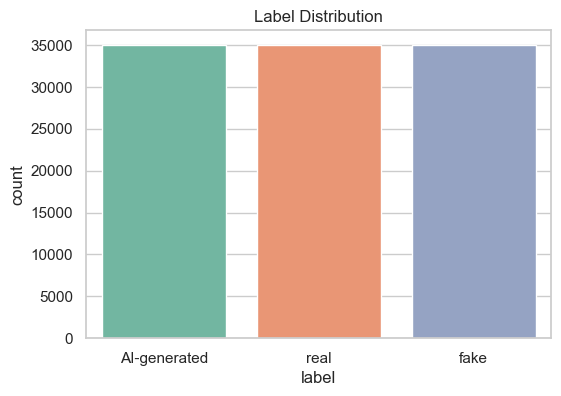

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=balanced_df, x='label', hue='label', palette="Set2")
plt.title('Label Distribution')
plt.show()

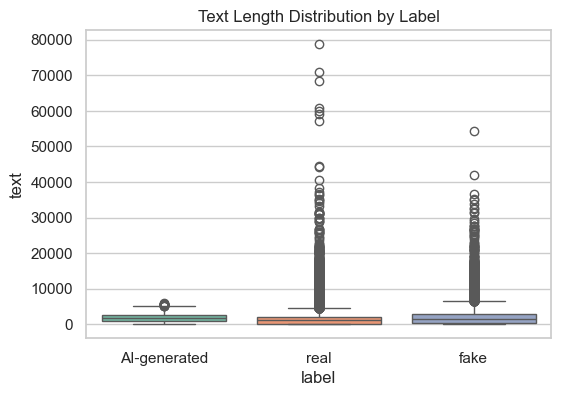

In [103]:
# Plot text length vs label
plt.figure(figsize=(6, 4))
sns.boxplot(data=balanced_df, x='label',hue='label', palette="Set2", y=balanced_df['text'].apply(len))
plt.title('Text Length Distribution by Label')
plt.show()

### WordClouds: Most Frequent Words in each Label

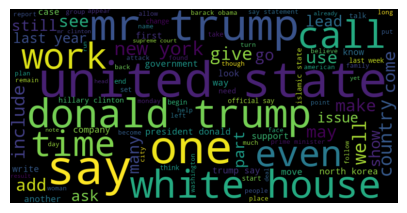

In [105]:
from wordcloud import WordCloud

wordcloud_text = ''.join(merged_df[merged_df['label']=='fake']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

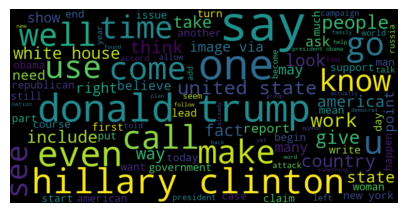

In [106]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='real']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

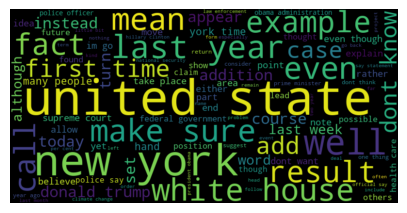

In [107]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='AI-generated']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### N-gram Analysis (Bigram/Trigram Frequency)

In [109]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [110]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [111]:
def get_top_ngrams(corpus, n=None, ngram_range=(2,2), max_features=50000):
    """Extracts the top N most common n-grams from the corpus"""
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=max_features)
    # Transform the corpus into a document-term matrix
    X = vectorizer.fit_transform(corpus)
    # Sum column-wise without converting to a dense array
    ngram_counts = X.sum(axis=0).A1  
    ngram_freq = list(zip(vectorizer.get_feature_names_out(), ngram_counts))
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:n]
    
    return ngram_freq

In [112]:
# Filter dataset by labels and convert to lists
real_news = balanced_df[balanced_df['label'] == 'real']['text'].tolist()
fake_news = balanced_df[balanced_df['label'] == 'fake']['text'].tolist()
ai_generated = balanced_df[balanced_df['label'] == 'AI-generated']['text'].tolist()

# Get the top 20 bigrams
real_bigrams = get_top_ngrams(real_news, n=20, ngram_range=(2,2))
fake_bigrams = get_top_ngrams(fake_news, n=20, ngram_range=(2,2))
ai_bigrams = get_top_ngrams(ai_generated, n=20, ngram_range=(2,2))

# Get the top 20 trigrams
real_trigrams = get_top_ngrams(real_news, n=20, ngram_range=(3,3))
fake_trigrams = get_top_ngrams(fake_news, n=20, ngram_range=(3,3))
ai_trigrams = get_top_ngrams(ai_generated, n=20, ngram_range=(3,3))

In [213]:
def plot_ngrams(ngram_freq, title):
    ngrams, counts = zip(*ngram_freq)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), hue=list(counts), y=list(ngrams), palette="viridis")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("N-grams")
    plt.show()

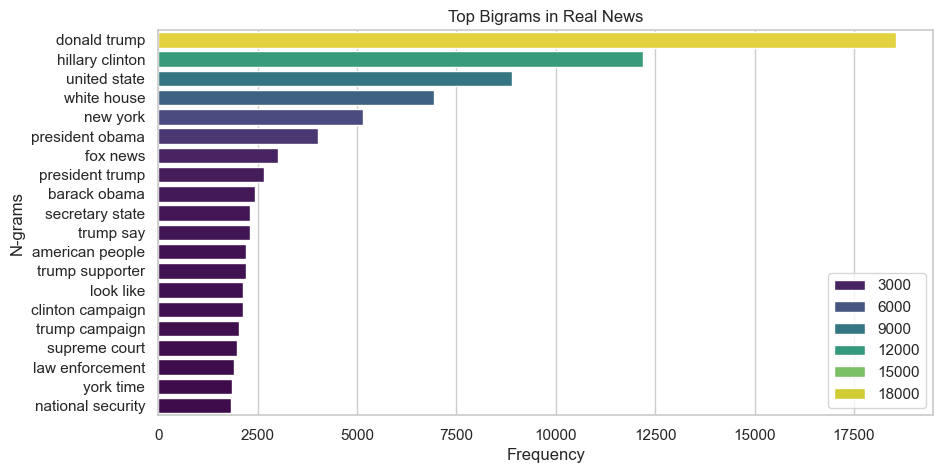

In [215]:
# Plot bigrams
plot_ngrams(real_bigrams, "Top Bigrams in Real News")

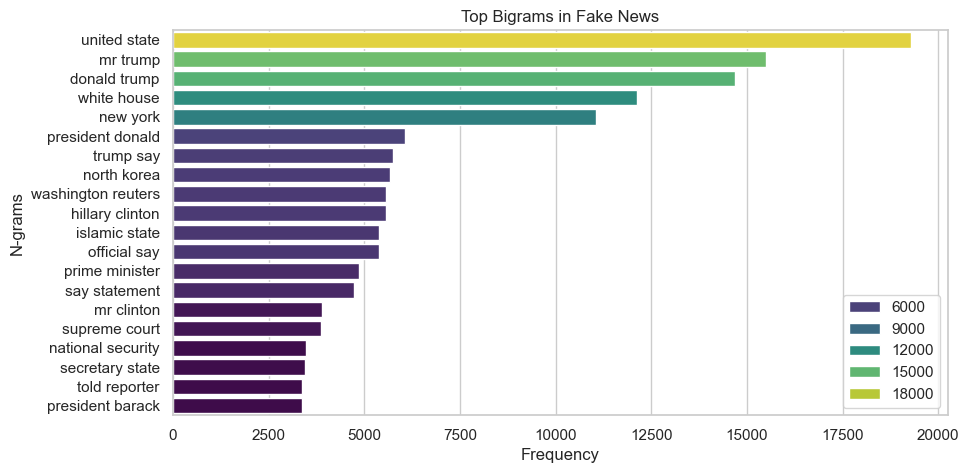

In [217]:
plot_ngrams(fake_bigrams, "Top Bigrams in Fake News")

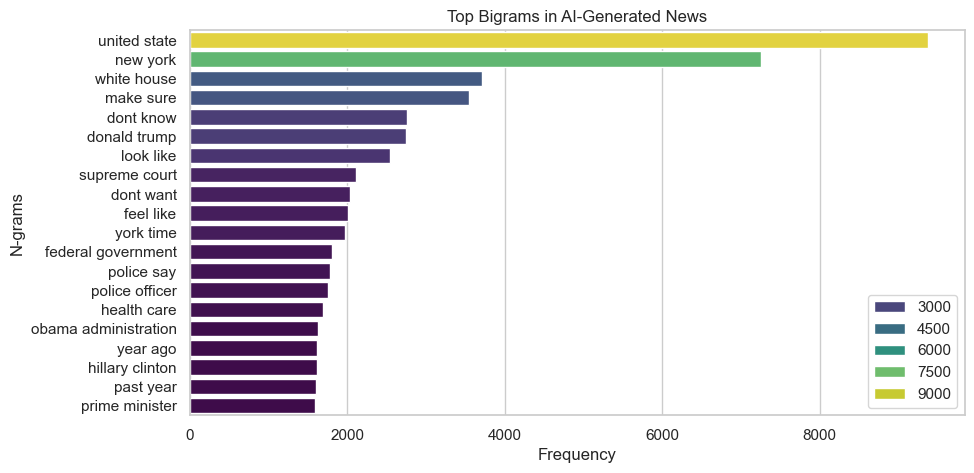

In [219]:
plot_ngrams(ai_bigrams, "Top Bigrams in AI-Generated News")

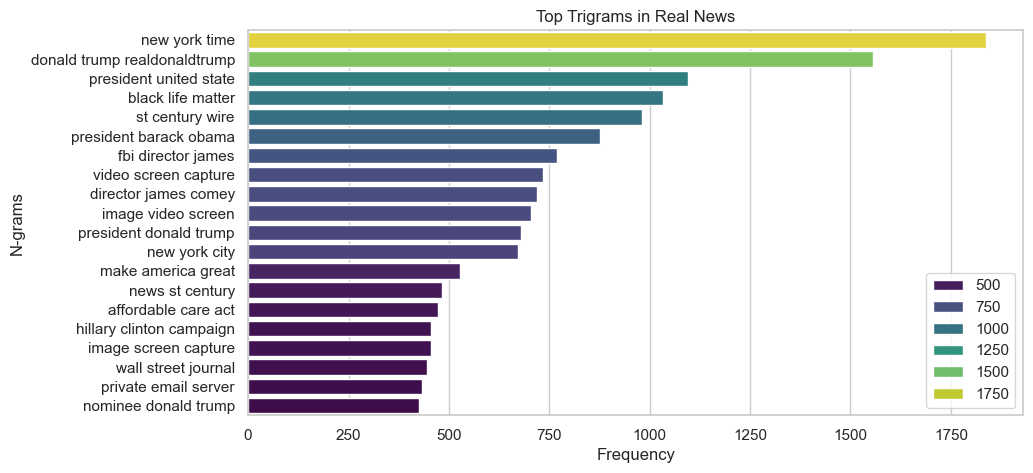

In [221]:
# Plot trigrams
plot_ngrams(real_trigrams, "Top Trigrams in Real News")

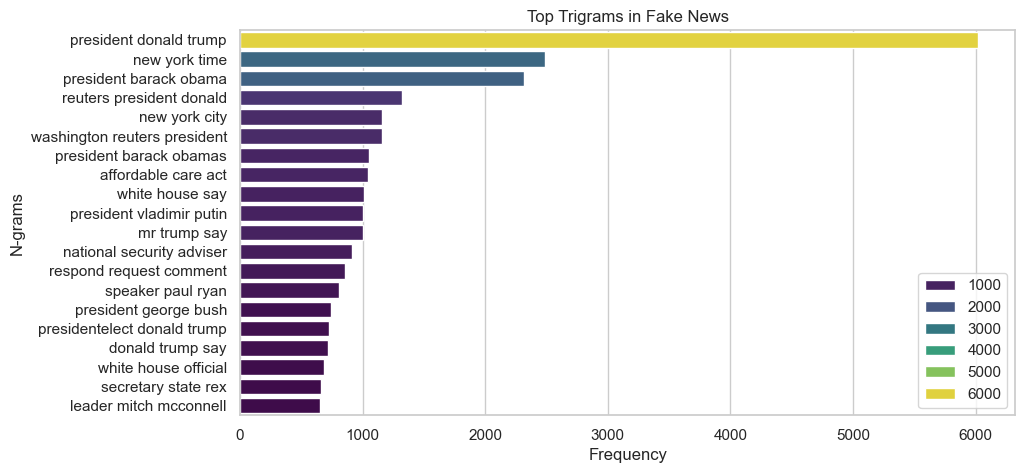

In [223]:
plot_ngrams(fake_trigrams, "Top Trigrams in Fake News")

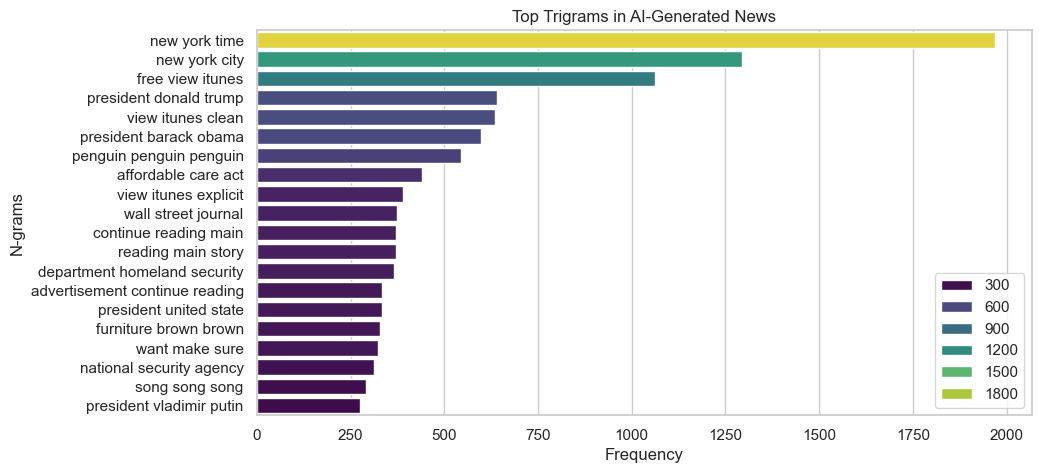

In [225]:
plot_ngrams(ai_trigrams, "Top Trigrams in AI-Generated News")

## 4. Baseline Modeling
### 4.1 Data Splitting
Spliting the dataset into training, validation, and testing sets:
- Training Set: 64% of the data
- Validation Set: 16% of the data
- Testing Set: 20% of the data

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% testing.
train_df, test_df = train_test_split(merged_df, test_size=0.2, stratify=merged_df['label'], random_state=42)
# Then taking 20% of the 80% training data (16% of the original dataset) for validation.
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

### 4.2 Vectorization with TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=10_000)
X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

If the labels are text strings ("fake", "real", "AI-generated"), they need to be encoded numerically for sklearn models. LabelEncoder or OneHotEncoder can be used.

In [ ]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

### 4.3 Training the Logistic Regression Model

In [ ]:
# Model Training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

In [ ]:
# Validation Predictions
y_pred = model.predict(X_val)

## 5. Model Evaluation

In [ ]:
# Print Accuracy Score
print(accuracy_score(y_val, y_pred))

In [ ]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

In [ ]:
# Test Predictions
y_test_pred = model.predict(X_test)
print("Test Metrics:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Investigating Different Methodologies
### 6. Word2Vec with Random Forest Classifier

In [ ]:
# print percentage of each label
print(merged_df['label'].value_counts(normalize=True) * 100)

In [ ]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [ ]:
merged_df.head(5)

In [ ]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, workers=4)

# Save the model for later use
word2vec_model.save("embeddings/word2vec.model")

In [ ]:
# Example: Access the vector for a specific word
example_vector = word2vec_model.wv["president"]

In [ ]:
print(example_vector)

In [ ]:
merged_df.to_csv("data/processed_data.csv", index=False)

In [ ]:
print(len(word2vec_model.wv.key_to_index))  # Number of words in the vocabulary

In [ ]:
print(word2vec_model.wv.most_similar("president"))  # Check related words

In [ ]:
print(word2vec_model.wv.most_similar("real", topn=5))

### Since Random Forest expects fixed-length feature vectors, we need to aggregate the Word2Vec embeddings as follows:
- Averaging Word Embeddings: Computing the mean of the word embeddings for all words in a document.

In [ ]:
# Compute the average embedding for a document
def compute_average_embedding(words, model, vector_size):
    valid_words = [word for word in words if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(vector_size)  # Handle empty documents
    return np.mean([model.wv[word] for word in valid_words], axis=0)

# Apply the function to tokenized text
vector_size = 100  # Same as used in Word2Vec model
merged_df['doc_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: compute_average_embedding(x, word2vec_model, vector_size)
)

In [ ]:
# Extract features and labels
X = np.stack(merged_df['doc_embedding'].values)  # Convert embeddings to a NumPy array
y = merged_df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

In [ ]:
# Predict on the test set
y_pred = rf_classifier.predict(X_test)

In [ ]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
merged_df.tail(5)

## Optuna Hyperparameter Tuning

In [ ]:
# import optuna
# from transformers import TrainingArguments, Trainer
# from sklearn.metrics import accuracy_score

# # Define a function to compute metrics
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# # Define the objective function for Optuna
# def objective(trial):
#     # Define hyperparameters to tune
#     learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
#     per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
#     num_train_epochs = trial.suggest_int("num_train_epochs", 2, 5)
#     weight_decay = trial.suggest_float("weight_decay", 0.01, 0.1)

#     # Define training arguments
#     training_args = TrainingArguments(
#         output_dir="./results",
#         eval_strategy="epoch",
#         learning_rate=learning_rate,
#         per_device_train_batch_size=per_device_train_batch_size,
#         per_device_eval_batch_size=16,
#         num_train_epochs=num_train_epochs,
#         weight_decay=weight_decay,
#         logging_dir="./logs",
#         save_strategy="no",  # Disable saving checkpoints to save disk space
#         report_to="none",  # Disable logging to external services
#         load_best_model_at_end=False,  # Disable loading the best model at the end
#     )

#     # Initialize Trainer
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=test_dataset,
#         compute_metrics=compute_metrics,  # Add the compute_metrics function
#     )

#     # Train the model
#     trainer.train()
    
#     # Evaluate the model
#     eval_results = trainer.evaluate()

#     # Extract the accuracy metric
#     accuracy = eval_results.get("eval_accuracy")
#     if accuracy is None:
#         raise ValueError("Evaluation did not return an accuracy metric.")

#     return accuracy

In [ ]:
# Initialize Optuna study
# study = optuna.create_study(direction="maximize")

In [ ]:
# # Start optimization
# study.optimize(objective, n_trials=10)

In [ ]:
# # Print the best hyperparameters
# print("Best hyperparameters:", study.best_params)

In [ ]:
# # Print best accuracy
# print("Best accuracy:", study.best_value)

## RNNs Trial

Next we will test RNNs and see if they perform better than DistilBERT.

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# encode the labels to integers
label_encoder = LabelEncoder()
merged_df['label_encoded'] = label_encoder.fit_transform(merged_df['label'])  # Convert labels to integers
num_classes = len(label_encoder.classes_)  # Number of unique labels

In [ ]:
# prepare train and test splits
X = merged_df['text']
y = to_categorical(merged_df['label_encoded'], num_classes=num_classes)  # One-hot encode the labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Tokenize and pad sequences
max_words = 5000  # Vocabulary size
max_len = 150  # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
# define the RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam

vocab_size = 10000
embedding_dim = 128

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

rnn_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Compile the model
rnn_model.summary()
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Multiclass loss function
    metrics=['accuracy']
)
rnn_model.summary()

In [ ]:
# Train the model
history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

In [ ]:
test_loss, test_accuracy = rnn_model.evaluate(X_test_padded, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Save the model for future use
rnn_model.save("models/rnn_model.keras")

In [ ]:
# Get predictions in probability form
y_pred_probs = rnn_model.predict(X_test_padded)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs with Word2Vec

In [ ]:
# Pad sequences with Word2Vec embeddings
def get_sequence_embedding(tokens, model, vector_size, max_seq_len):
    sequence = []
    for word in tokens[:max_seq_len]:  # Truncate to max sequence length
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))  # Handle OOV words
    # Pad sequence if it's shorter than max_seq_len
    while len(sequence) < max_seq_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

In [ ]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [ ]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [ ]:
# Define maximum sequence length for LSTM and vector size
max_seq_len = 150
vector_size = 100

# Compute sequence embeddings for each document
merged_df['sequence_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: get_sequence_embedding(x, word2vec_model, vector_size, max_seq_len)
)

In [ ]:
# Stack the sequences correctly for LSTM input
X = np.array(list(merged_df['sequence_embedding'].values))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set shape for LSTM: {X_train.shape}")

In [ ]:
print(f"Expected shape: (samples, timesteps, features) -> {X_train.shape[0], max_seq_len, vector_size}")

In [ ]:
# Load the Word2Vec embeddings
embedding_matrix = np.zeros((len(word2vec_model.wv), vector_size))
word_index = {word: idx for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word_index.items():
    embedding_matrix[idx] = word2vec_model.wv[word]

In [ ]:
# Build the RNN model
word2vec_lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, input_shape=(max_seq_len, vector_size))),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [ ]:
# Compile the model
word2vec_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
print(word2vec_lstm_model.summary())

In [ ]:
# train the model
history = word2vec_lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

In [ ]:
test_loss, test_accuracy = word2vec_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
print(X_test_padded.shape)  # Should output (num_samples, max_sequence_length)

In [ ]:
# Get predictions in probability form
y_pred_probs = word2vec_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the model for future use
rnn_model.save("models/lstm_model.keras")

## RNNs with GloVe Embeddings.
The dataset is already tokenized and preprocessed. Now, we need to:
- Load pre-trained GloVe embeddings.
- Create an embedding matrix for the vocabulary.
- Convert the tokenized text into sequences of GloVe embeddings.

In [ ]:
import torch

# Load GloVe embeddings
def load_glove_embeddings(glove_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_path = "GloVe_embeddings/glove.6B.100d.txt"  # Path to GloVe file
glove_embeddings = load_glove_embeddings(glove_path)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(merged_df['text'])

# Convert the text to sequences of integers
X = tokenizer.texts_to_sequences(merged_df['text'])
max_seq_len = 150  # Maximum sequence length for padding

# Pad the sequences to ensure equal length
X = pad_sequences(X, maxlen=max_seq_len)

# One-hot encode the labels
y = pd.get_dummies(merged_df['label']).values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Get the vocabulary size from the tokenizer
tokenizer_vocab_size = len(tokenizer.word_index) + 1  # Including padding token

# Set the embedding dimension (100 for GloVe 100d embeddings)
embedding_dim = 100

# Initialize the embedding matrix with zeros
embedding_matrix = np.zeros((tokenizer_vocab_size, embedding_dim))

# Map GloVe embeddings to the tokenizer's word index
for word, i in tokenizer.word_index.items():
    if i >= tokenizer_vocab_size:  # Skip words outside of the tokenizer's vocab
        break
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
# Build the RNN model using Bidirectional LSTM with GloVe embeddings
glove_lstm_model = Sequential([
    # Use the pretrained GloVe embeddings with non-trainable weights
    Embedding(input_dim=tokenizer_vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),  # Use non-trainable GloVe embeddings
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [ ]:
# Compile the model
glove_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

In [ ]:
# Model summary
glove_lstm_model.summary()

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
# Train the model
glove_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = glove_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Get predictions in probability form
y_pred_probs = glove_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs LSTM with FastText

In [ ]:
pip install fasttext

In [ ]:
pip install gensim

In [ ]:
merged_df.head(5)

In [ ]:
import gensim
import numpy as np

# Load FastText vectors using gensim
fasttext_model_path = 'embeddings/wiki-news-300d-1M-subword.vec'  # Path to the unzipped .vec file
fasttext_model = gensim.models.KeyedVectors.load_word2vec_format(fasttext_model_path, binary=False)

In [ ]:
embedding_dim = 300  # FastText vectors are 300-dimensional

# Create an embedding matrix
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, embedding_dim))

for word, i in tokenizer.word_index.items():
    try:
        # Get FastText vector for the word
        embedding_vector = fasttext_model[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        # If the word is not in the FastText vocabulary, leave as zeros
        embedding_matrix[i] = np.zeros(embedding_dim)

In [ ]:
# Build the model
fasttext_lstm_model = Sequential([
    # Use the pretrained FastText embeddings with non-trainable weights
    Embedding(input_dim=len(tokenizer.word_index) + 1,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),  # Don't train the FastText embeddings
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

# Compile the model
fasttext_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
fasttext_lstm_model.summary()

In [ ]:
history = fasttext_lstm_model.fit(X_train, y_train, 
                    epochs=10,  
                    batch_size=32,
                    validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = fasttext_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Get predictions in probability form
y_pred_probs = fasttext_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs with CNNs layers.
Combining CNN and RNN layers is a powerful approach for text classification tasks, where CNNs capture local patterns, and RNNs handle sequential dependencies. 
Since Word2Vec was the best performing embedding with LSTM we will use here as well:

In [ ]:
# Load and pad the Word2Vec embedding vectors
def get_sequence_embedding(tokens, model, vector_size, max_seq_len):
    sequence = []
    for word in tokens[:max_seq_len]:  # Truncate to max sequence length
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))  # Handle OOV words
    # Pad sequence if it's shorter than max_seq_len
    while len(sequence) < max_seq_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

# Compute sequence embeddings for each document
merged_df['sequence_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: get_sequence_embedding(x, word2vec_model, vector_size, max_seq_len)
)

# Stack the sequences correctly for model input
X = np.array(list(merged_df['sequence_embedding'].values))
print(f"Input shape: {X.shape}")  # Ensure shape is (num_samples, max_seq_len, vector_size)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Input

# Build the CNN + BiLSTM model
cnn_rnn_model = Sequential([
    Input(shape=(max_seq_len, vector_size)),  # Explicit input layer
    # CNN layers
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Dropout(0.5),

    # RNN layers
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.5),

    # Fully connected layers
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # Three output classes: Real, Fake, AI-generated
])

In [ ]:
# Compile the model
cnn_rnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [ ]:
# Model summary
cnn_rnn_model.summary()

In [ ]:
# Train the model
history = cnn_rnn_model.fit(X_train, 
                            y_train, 
                            epochs=10, 
                            batch_size=32, 
                            validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = cnn_rnn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Get predictions in probability form
y_pred_probs = cnn_rnn_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Train the model
history = cnn_rnn_model.fit(X_train, 
                            y_train, 
                            epochs=20, 
                            batch_size=64, 
                            validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = cnn_rnn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Get predictions in probability form
y_pred_probs = cnn_rnn_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RoBERTa Trial
Decided to investigate a stronger model than DistilBERT to see if we can achieve even higher results.

In [ ]:
merged_df.head()

In [ ]:
merged_df.drop(['tokenized_text'], axis=1, inplace=True)

In [ ]:
merged_df.drop(['label_encoded'], axis=1, inplace=True)

In [ ]:
merged_df.drop(['sequence_embedding'], axis=1, inplace=True)

In [ ]:
merged_df.head()

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load RoBERTa tokenizer and model
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

In [ ]:
# Convert DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(merged_df)

# Split into train and test sets
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [ ]:
# Tokenize function
def tokenize_function(example):
    return roberta_tokenizer(example["text"], padding="max_length", truncation=True, max_length=512)

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

In [ ]:
# Remove unused columns
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# Set format for PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [ ]:
# Map labels to numeric values
label_map = {"fake": 0, "real": 1, "AI-generated": 2}

train_dataset = train_dataset.map(lambda x: {"label": label_map[x["label"]]})
test_dataset = test_dataset.map(lambda x: {"label": label_map[x["label"]]})

In [ ]:
# Define training arguments
roberta_training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",        # Save the best model at the end of every epoch
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    save_total_limit=2,
    load_best_model_at_end=True,
)

# Initialize Trainer
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [ ]:
# Train the model
roberta_trainer.train()

In [ ]:
# Evaluate the model
roberta_trainer.evaluate()

In [ ]:
# Save the model and tokenizer
roberta_model.save_pretrained("models/roberta-finetuned")
roberta_tokenizer.save_pretrained("models/roberta-finetuned")

In [ ]:
# Get predictions and true labels
roberta_predictions = trainer.predict(test_dataset)
roberta_pred_labels = predictions.predictions.argmax(axis=-1)
roberta_true_labels = test_dataset["label"]

In [ ]:
print("Accuracy:", accuracy_score(roberta_true_labels, roberta_pred_labels))

In [ ]:
print("Classification Report:\n", classification_report(roberta_true_labels, roberta_pred_labels, target_names=["Fake", "Real", "AI-generated"]))

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(roberta_true_labels, roberta_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## DistilBERT Re-Implementation
downgrading to DistilBERT to compare with RoBERTa

In [ ]:
merged_df.head()

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# Load tokenizer and model
distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

In [ ]:
from datasets import Dataset

# Convert pandas DataFrame to a Hugging Face Dataset
dataset = Dataset.from_pandas(merged_df)

# Split the dataset into train and test sets
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset['train']
test_dataset = dataset['test']

In [ ]:
def tokenize_function(example):
    return distilbert_tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove unused columns and set format for PyTorch
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [ ]:
# Map the labels to numeric values
label_map = {'fake': 0, 'real': 1, 'AI-generated': 2}

train_dataset = train_dataset.map(lambda x: {'label': label_map[x['label']]})
test_dataset = test_dataset.map(lambda x: {'label': label_map[x['label']]})

In [ ]:
from transformers import TrainingArguments, Trainer

# Define model
distilbert_training_args = TrainingArguments(
    output_dir="./distil_results",
    eval_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",        # Save the best model at the end of every epoch
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.1,
    logging_dir="./distil_logs",
    load_best_model_at_end=True,
)

In [ ]:
from transformers import EarlyStoppingCallback
from transformers import get_scheduler
from torch.optim import AdamW

# Define the optimizer
optimizer = AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=0.1)

# Total training steps
num_training_steps = len(train_dataset) // distilbert_training_args.per_device_train_batch_size * distilbert_training_args.num_train_epochs


# Define a linear learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

In [ ]:
# Initialize trainer
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    optimizers=(optimizer, lr_scheduler)
)

# Train the model
distilbert_trainer.train()

In [ ]:
# Evaluate the model
distilbert_trainer.evaluate()

In [ ]:
# Save model for later use
distilbert_model.save_pretrained("models/distilbert-finetuned")
distilbert_tokenizer.save_pretrained("models/distilbert-finetuned")

In [ ]:
# Get predictions and true labels from the trainer
distilbert_predictions = trainer.predict(test_dataset)
distilbert_pred_labels = predictions.predictions.argmax(axis=-1)
distilbert_true_labels = test_dataset['label']

In [ ]:
# Evaluate performance
print("Accuracy:", accuracy_score(distilbert_true_labels, distilbert_pred_labels))

In [ ]:
print("Classification Report:\n", classification_report(distilbert_true_labels, distilbert_pred_labels))

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(distilbert_true_labels, distilbert_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Paste training & validation losses of each epoch
epochs = [1, 2, 3, 4]
train_losses = [0.176800, 0.129600, 0.101700, 0.074800]
val_losses = [0.154004, 0.142378, 0.157832, 0.240578]

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from scipy.special import softmax

# Extract logits from predictions
logits = distilbert_predictions.predictions

# Convert logits to probabilities using softmax
probabilities = softmax(logits, axis=-1)

In [ ]:
from sklearn.preprocessing import label_binarize

# Assuming `distilbert_true_labels` contains integer class labels
num_classes = len(np.unique(distilbert_true_labels))
true_labels_one_hot = label_binarize(distilbert_true_labels, classes=np.arange(num_classes))

In [ ]:
# Plot ROC for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    # Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], probabilities[:, i])
    # Compute AUC for the current class
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve for the current class with its AUC value in the legend
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for random guessing
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Create a new figure for the precision-recall curves
plt.figure(figsize=(10, 6))

# Plot the precision-recall curve for each class
for i in range(num_classes):
    # Compute precision, recall, and thresholds for class i
    precision, recall, _ = precision_recall_curve(true_labels_one_hot[:, i], probabilities[:, i])
    
    # Compute AUC for the precision-recall curve
    pr_auc = auc(recall, precision)
    
    # Plot the precision-recall curve for the current class
    plt.plot(recall, precision, label=f"Class {i} (AUC = {pr_auc:.2f})")

# Add plot title and axis labels
plt.title("Multi-Class Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

# Display legend for class labels
plt.legend()

# Show the plot
plt.show()
